# ANTEX parsers

Antenna Exchange Format ([ANTEX](https://files.igs.org/pub/data/format/antex14.txt)) isstandard text format for the exchnge of GNSS antenna calibration data. Midgard provides a parser for reading the ANTEX format.

## Use of ANTEX parser

An example is shown, how to use the **antex** parser:

In [1]:
# Import parsers package
from midgard import parsers

# Read file by generating an instance of a Parser class
p = parsers.parse_file(parser_name="antex", file_path="../examples/parsers/igs20.atx")

# Generate dictionary based on read file data
data = p.as_dict()

The **data** dictionary has GNSS satellite PRN or receiver antenna as key. The GNSS satellite antenna corrections are time dependent and saved with "valid from" datetime object entry. The dictionary looks like:

```
        dout = { <prn> : { <valid from>: { cospar_id:   <value>,
                                           sat_code:    <value>,
                                           sat_type:    <value>,
                                           valid_until: <value>,
                                           azimuth:     <list with azimuth values>,
                                           elevation:   <list with elevation values>,
                                           <frequency>: { azi: [<list with azimuth-elevation dependent corrections>],
                                                          neu: [north, east, up],
                                                          noazi: [<list with elevation dependent corrections>] }}},

                 <receiver antenna> : { azimuth:     <list with azimuth values>,
                                        elevation:   <list with elevation values>,
                                        <frequency>: { azi: [<array with azimuth-elevation dependent corrections>],
                                                       neu: [north, east, up],
                                                       noazi: [<list with elevation dependent corrections>] }}}
                                                       
```
with following entries:

| Value              | Type              | Description                                                            |
| :----------------- | :---------------- | :--------------------------------------------------------------------- |
| azi                | numpy.ndarray     | Array with azimuth-elevation dependent antenna correction in [m] with  |
|                    |                   | the shape: number of azimuth values x number of elevation values.      |
| azimuth            | numpy.ndarray     | List with azimuth values in [rad] corresponding to antenna corrections |
|                    |                   | given in `azi`.                                                        |
| cospar_id          | str               | COSPAR ID <yyyy-xxxa>: yyyy -> year when the satellite was put in      |
|                    |                   | orbit, xxx -> sequential satellite number for that year, a -> alpha    |
|                    |                   | numeric sequence number within a launch                                |
| elevation          | numpy.ndarray     | List with elevation values in [rad] corresponding to antenna           |
|                    |                   | corrections given in `azi` or `noazi`.                                 |
| <frequency>        | str               | Frequency identifier (e.g. G01 - GPS L1)                               |
| neu                | list              | North, East and Up eccentricities in [m]. The eccentricities of the    |
|                    |                   | mean antenna phase center is given relative to the antenna reference   |
|                    |                   | point (ARP) for receiver antennas or to the center of mass of the      |
|                    |                   | satellite in X-, Y- and Z-direction.                                   |
| noazi              | numpy.ndarray     | List with elevation dependent (non-azimuth-dependent) antenna          |
|                    |                   | correction in [m].                                                     |
| <prn>              | str               | Satellite code e.g. GPS PRN, GLONASS slot or Galileo SVID number       |
| <receiver antenna> | str               | Receiver antenna name together with radome code                        |
| sat_code           | str               | Satellite code e.g. GPS SVN, GLONASS number or Galileo GSAT number     |
| sat_type           | str               | Satellite type (e.g. BLOCK IIA)                                        |
| valid_from         | datetime.datetime | Start of validity period of satellite in GPS time                      |
| valid_until        | datetime.datetime | End of validity period of satellite in GPS time                        |


## Usage examples
In the following it is shown how to plot the satellite phase center offsets (PCOs). 

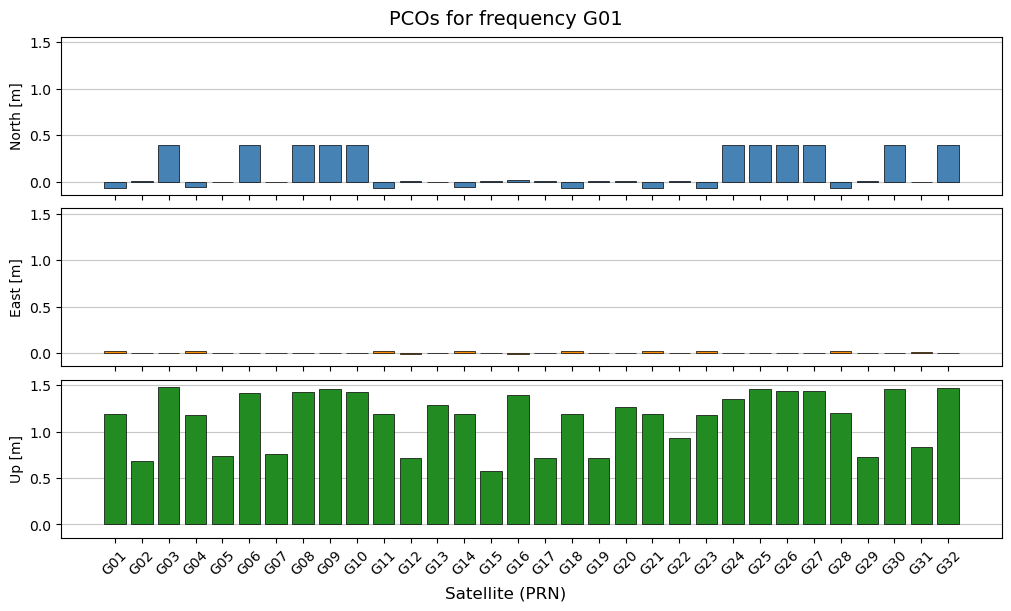

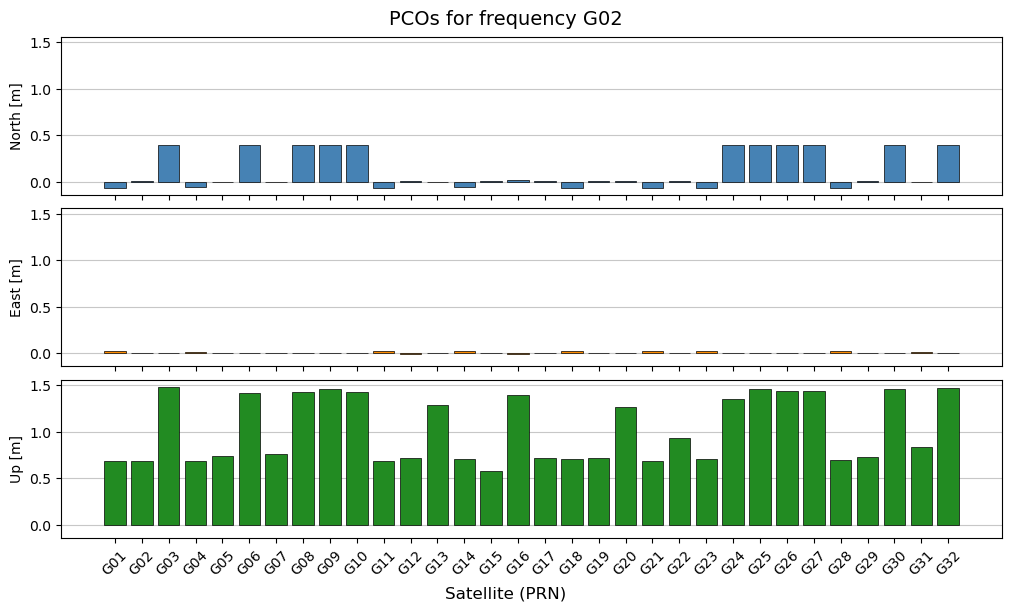

In [12]:
# Standard library imports
import re

# Third party imports
import matplotlib.pyplot as plt

# 1. Prepare data by ordering the PCOs for frequency and satellite related
#__________________________________________________________________________
pco = dict()

# Loop over satellite entries
for sat in data.keys():

    # Get only satellite entries
    if re.match(r'^[a-zA-Z]\d{2}$', sat):

        # Get last date entry
        last_date = list(data[sat].keys())[-1]

        # Get PCOs for frequency entries
        for freq in data[sat][last_date].keys():
            
            if re.match(r'^[a-zA-Z]\d{2}$', freq):
                pco.setdefault(freq, dict()).update({sat: data[sat][last_date][freq]["neu"]})


# 2. Plot PCOs for each frequency
#__________________________________________________________________________
for freq in ["G01", "G02"]: # In case of PCOs for all frequency should be plotted than use 'pco.keys()'
    fig, axes = plt.subplots(3, 1, sharex=True, sharey=True, layout="constrained", figsize=(10,6))
    fig.suptitle(f"PCOs for frequency {freq}", fontsize=14)
    
    sats = list(pco[freq].keys())
    labels = ["North [m]", "East [m]", "Up [m]"]
    colors = ["steelblue", "darkorange", "forestgreen"]

    for i, (ax, label, color) in enumerate(zip(axes, labels, colors)):
        # Extract values for the actual component (i=0: N, 1: E, 2: U)
        values = [pco[freq][sat][i] for sat in sats]

        ax.set_axisbelow(True)
        ax.grid(axis='y', linestyle='-', alpha=0.7) 
        ax.bar(sats, values, color=color, edgecolor="black", linewidth=0.5)
        ax.set_ylabel(label)

    axes[-1].tick_params(axis="x", labelrotation=45)
    fig.supxlabel("Satellite (PRN)")

    plt.show()      

An example is given how to plot phase center variations (PCV) for a defined antenna (antenna type + radome type).

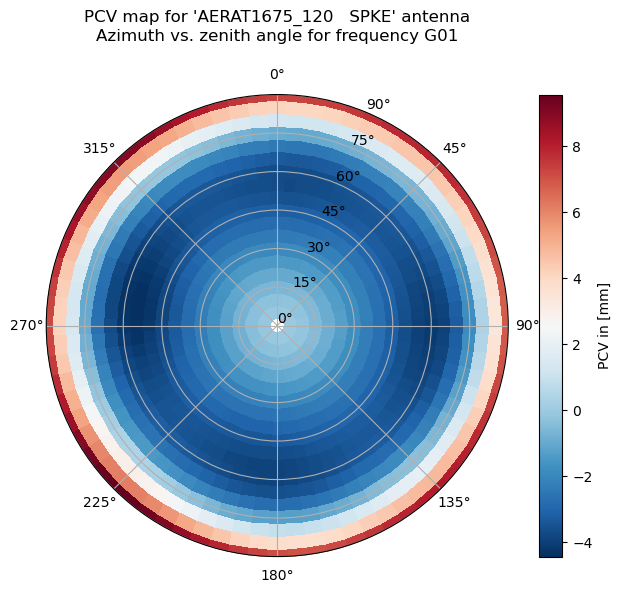

In [15]:
# Third party imports
import matplotlib.pyplot as plt
import numpy as np

# Midgard imports
from midgard.math.unit import Unit

# 1. Choose PCVs for given antenna/radome type and frequency
#____________________________________________________________
ant_type = "AERAT1675_120   SPKE"
freq = "G01"

# Get PCV 2D Data Array (19x73)  (19 rows representing the zenith angle from 0° to 90° and 73 columns with represents 
# the azimuth from  0° to 360° in 5° steps)
pcv = data[ant_type][freq]["azi"] * Unit.meter2millimeter

# 2. Define grid based on ANTEX file format definition
#______________________________________________________
# DAZI = 5.0, ZEN1 = 0.0, ZEN2 = 90.0, DZEN = 5.0
zenith = np.arange(0, 95, 5) # 0, 5, ..., 90 (19 values)
azimuth = np.arange(0, 365, 5)    # 0, 5, ..., 360 (full circle)
theta, r = np.meshgrid(np.radians(azimuth), zenith) # azimuth has to be converted from degree to radian

# 3. Generate Plot
#__________________
fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(8, 6))
ax.set_theta_zero_location("N") # North at top
ax.set_theta_direction(-1) # Clockwise

# Plot using pcolormesh (pcv must be transposed to match meshgrid)
pc = ax.pcolormesh(theta, r, pcv.T, cmap="RdBu_r", shading="auto")

# Customizing ticks for zenith angle (0 to 90 degrees)
ax.set_ylim(0, 90)
ax.set_yticks([0, 15, 30, 45, 60, 75, 90])
ax.set_yticklabels(["0°", "15°", "30°", "45°", "60°", "75°", "90°"])

plt.colorbar(pc, label="PCV in [mm]")
plt.title(f"PCV map for '{ant_type}' antenna\nAzimuth vs. zenith angle for frequency {freq}", pad=20)
plt.show()

An example is given how to plot phase center offsets (PCO) for a defined receiver antenna (antenna type + radome type) as 2D and 3D plot.

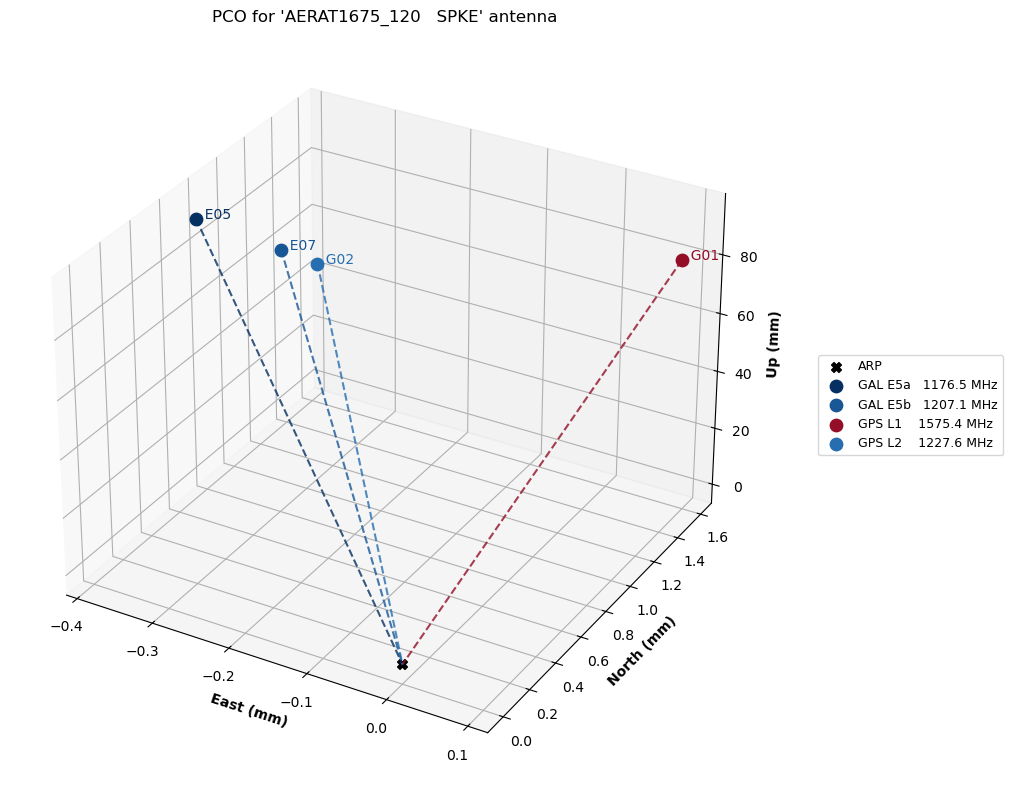

In [3]:
# Standard library imports
from collections import namedtuple
import re

# Third party imports
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

# Midgard imports
from midgard.math.unit import Unit

PlotField = namedtuple(
    "PlotField", ["name", "color", "freq"]
)

color_freq_def = {
    "I09": PlotField("IRN S", "lightgrey", 2492.028e6),
    "R01": PlotField("GLO L1", "rosybrown", 1602.00e6),
    "C01": PlotField("BDS B1", "orangered", 1575.42e6),
    "E01": PlotField("GAL E1", "orangered", 1575.42e6),
    "G01": PlotField("GPS L1", "orangered", 1575.42e6),    
    "I01": PlotField("IRN L1", "orangered", 1575.42e6), 
    "J01": PlotField("QZS L1", "orangered", 1575.42e6),
    "S01": PlotField("SBS L1", "orangered", 1575.42e6),
    "C02": PlotField("BDS B1_2", "chocolate", 1561.098e6),
    "E06": PlotField("GAL E6", "gold", 1278.75e6),
    "J06": PlotField("QZS L6", "goldenrod", 1278.75e6),
    "C06": PlotField("BDS B3", "goldenrod", 1268.52e6),
    "R02": PlotField("GLO L2", "yellow", 1246.00e6),
    "G02": PlotField("GPS L2", "olive", 1227.60e6),
    "J02": PlotField("QZS L2", "olive", 1227.60e6),
    "C07": PlotField("BDS B2b", "orchid", 1207.14e6),    
    "E07": PlotField("GAL E5b", "orchid", 1207.140e6),
    "C08": PlotField("BDS B2", "darkviolet", 1191.795e6),
    "E08": PlotField("GAL E5", "darkviolet", 1191.795e6),
    "C05": PlotField("BDS B2a", "cornflowerblue", 1176.45e6),
    "E05": PlotField("GAL E5a", "cornflowerblue", 1176.45e6),
    "G05": PlotField("GPS L5", "cornflowerblue", 1176.45e6),    
    "I05": PlotField("IRN L5", "cornflowerblue", 1176.45e6),
    "J05": PlotField("QZS L5", "cornflowerblue", 1176.45e6),
    "S05": PlotField("SBS L2", "cornflowerblue", 1176.45e6),
}

# 1. Choose PCVs for given antenna/radome type and frequency
#____________________________________________________________
ant_type = "AERAT1675_120   SPKE"
used_freqs = ["E05", "E07", "G01", "G02"]


# 2. Prepare PCO data
#_____________________
pco = {}
for freq in sorted(data[ant_type].keys()):

    if freq in used_freqs:
        
        # Get only frequency entries
        if re.match(r"^[a-zA-Z]\d{2}$", freq):
            pco[freq] = [ v * Unit.meter2millimeter for v in data[ant_type][freq]["neu"]]

# 3. Generate 3D Plot
#____________________

# Define colors and color scale range
norm = colors.Normalize(vmin=1176.45e6, vmax=1602.00e6)
mapper = cm.ScalarMappable(norm=norm, cmap="RdBu_r")

# Initialize plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot the ARP as a reference at the origin
ax.scatter(0, 0, 0, color="black", marker="X", s=50, label="ARP")

# Plot each frequency's Phase Center Offset
for freq, neu in pco.items():
    n, e, u = neu
    color = mapper.to_rgba(color_freq_def[freq].freq)
    ax.scatter(
            e, n, u, 
            s=80, 
            color=color, # or use as alternative 'color=color_freq_def[freq].color'
            label=f"{color_freq_def[freq].name:9s} {color_freq_def[freq].freq*1e-6:.1f} MHz",
    )
    ax.text(e, n, u, f"  {freq}", color=color)

    # 2. Legg til vektor (pil) fra ARP (0,0,0) til punktet
    ax.quiver(
        0, 0, 0,   # ARP starting point
        e, n, u,
        color=color,
        length=1.0,     # length=1.0 avoids scaling of vector
        linestyle='--',
        normalize=False,    # Important for showing normal length of vector
        arrow_length_ratio=0.0, # Size of arrow (Note: The arrow looks strange, therefore the arrow is not shown)
        pivot="tail",
        alpha=0.8
    )

#ax.set_box_aspect([1,1,1])
ax.set_xlabel("East (mm)", fontweight="bold")
ax.set_ylabel("North (mm)", fontweight="bold")
ax.set_zlabel("Up (mm)", fontweight="bold")
ax.set_title(f"PCO for '{ant_type}' antenna")
ax.legend(loc="center left", bbox_to_anchor=(1.07, 0.5), ncol=1, fontsize=9, frameon=True)
plt.tight_layout()
plt.show()


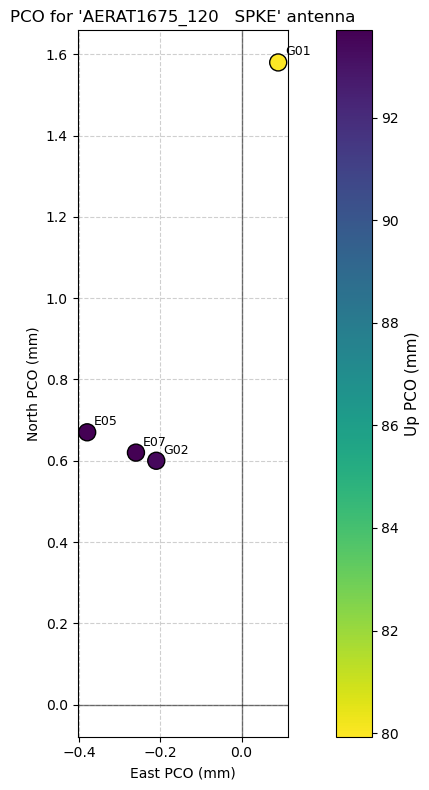

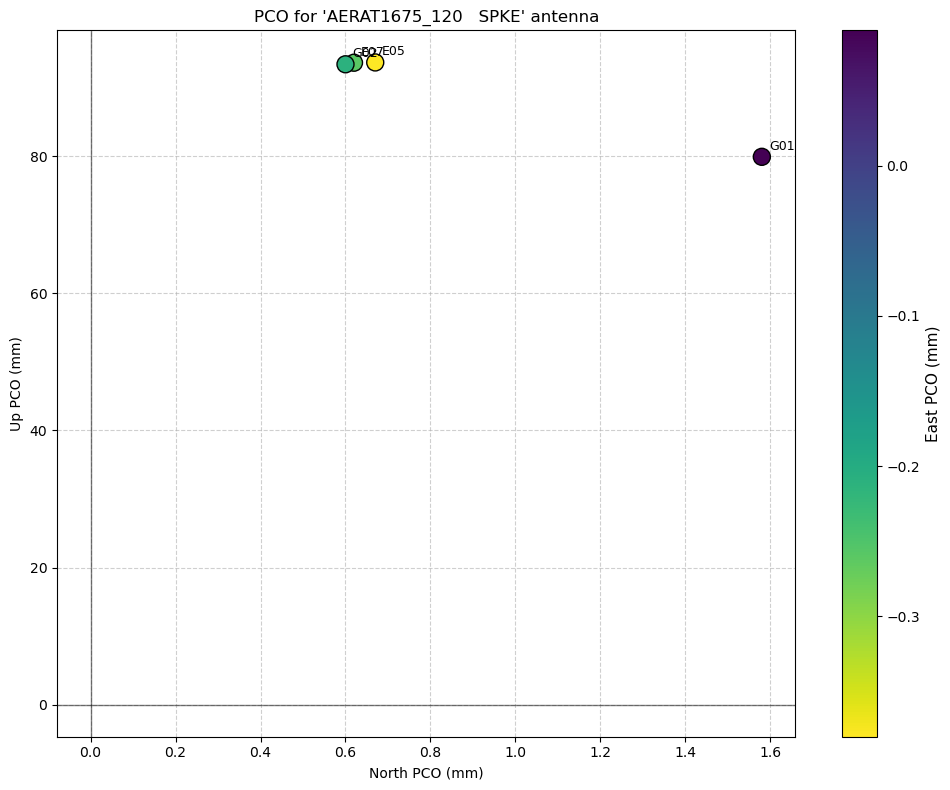

In [17]:

# 4. Prepare data for 2D plot
#_____________________________
north = [ pco[f][0] for f in pco.keys() ]
east = [ pco[f][1] for f in pco.keys() ]
up = [ pco[f][2] for f in pco.keys() ]
labels = [ f for f in pco.keys()]

# 5. Generate 2D Plot (east, north)
#__________________________________
fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(east, north, c=up, cmap="viridis_r", s=150, 
                edgecolors="black", zorder=3)

# Define colorbar with Up PCO
cbar = plt.colorbar(sc)
cbar.set_label("Up PCO (mm)", fontsize=11)

# Add annotations
for i, label in enumerate(labels):
    ax.annotate(label, (east[i], north[i]), xytext=(5, 5), 
                textcoords="offset points", fontsize=9)

ax.axhline(0, color="black", lw=1, alpha=0.5)
ax.axvline(0, color="black", lw=1, alpha=0.5)
ax.set_xlabel("East PCO (mm)")
ax.set_ylabel("North PCO (mm)")
ax.set_title(f"PCO for '{ant_type.strip()}' antenna")
ax.grid(True, linestyle="--", alpha=0.6)

ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()
plt.close()

# 6. Generate 2D Plot (north, up)
#__________________________________
fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(north, up, c=east, cmap="viridis_r", s=150, 
                edgecolors="black", zorder=3)

# Define colorbar with East PCO
cbar = plt.colorbar(sc)
cbar.set_label("East PCO (mm)", fontsize=11)

# Add annotations
for i, label in enumerate(labels):
    ax.annotate(label, (north[i], up[i]), xytext=(5, 5), 
                textcoords="offset points", fontsize=9)

ax.axhline(0, color="black", lw=1, alpha=0.5)
ax.axvline(0, color="black", lw=1, alpha=0.5)
ax.set_xlabel("North PCO (mm)")
ax.set_ylabel("Up PCO (mm)")
ax.set_title(f"PCO for '{ant_type.strip()}' antenna")
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()
